
<h1> COAD PREPROCESS (noRIN & RIN) </h1>

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

# CONSTANTES
ROTULO    = 'Deleteria11'
TEST_SIZE = 0.2

HIGH_CARD = ['Gene_EFF', 'aminBefore', 'aminAfter', 'groupChange', 'Tecido']
LOW_CARD  = ['REF', 'ALT', 'VariantEffect_EFF', 'essencialChange']

COLUNAS_RIN_EXCL = [
    'Degree_RING', 'Bfactor_CA_RING', 'triangles_node',
    'clusteringCoef_node', 'betweennessWeighted_node',
    'Inter_Lig_tot', 'Inter_Res_tot', 'Inter_IAC_Lig_tot',
    'Inter_VDW_Lig_tot', 'Inter_VDW_Res_tot', 'Inter_HBOND_Res_tot',
    'Inter_PIPISTACK_Res_tot', 'Inter_IONIC_Res_tot', 'Inter_PICATION_Res_tot',
]

# 1. Leitura dos Dataset.
> No `coad_extractor.ipynb` presente no repositório, já existe a metodologia de separação do dataset geral ([`Base_33Tecidos_cleancomDeleteria11.csv`](https://github.com/TailUFPB/BioInfo-2026.1/blob/COAD/data/Base_33Tecidos_cleancomDeleteria11.csv)) entre os atributos removidos para o modelo de aprendizado de máquina, além da filtragem dos atributos de "com" e "sem" RIN. 

> Desse modo, podemos fazer a leitura direta dos dataset separados, também presentes na pasta "[data](https://github.com/TailUFPB/BioInfo-2026.1/tree/COAD/data)".

Os arquivos já estão filtrados pelo `coad_extractor.ipynb` conforme as Tabelas 14–16 da tese:

- `COAD_noRIN.csv` — 17 colunas (15 features + `Tecido` + `Deleteria11`)
- `COAD_RIN.csv` — 31 colunas (+ 14 features RIN)

In [0]:
coad_norin = pd.read_csv('https://raw.githubusercontent.com/TailUFPB/BioInfo-2026.1/refs/heads/COAD/data/COAD_noRIN.csv',  sep='\t')
coad_rin = pd.read_csv('https://raw.githubusercontent.com/TailUFPB/BioInfo-2026.1/refs/heads/COAD/data/COAD_RIN.csv', sep='\t')

import IPython.display as ipd

# Configurar pandas para não truncar o conteúdo das células
pd.set_option('display.max_colwidth', None)

# Tabela resumo shapes e colunas
summary_coad_norin = pd.DataFrame({
    'Dataset': ['SEM RIN', 'COM RIN'],
    'Shape': [str(coad_norin.shape), str(coad_rin.shape)],
})
display(summary_coad_norin)

# Distribuição do alvo (apenas 0 e 1)
alvo_dist = coad_rin[ROTULO].value_counts().loc[[0,1]].to_frame('Distribuição do alvo').reset_index()
alvo_dist.columns = [ROTULO, 'Distribuição do alvo']
display(alvo_dist)

print(f'Colunas COM RIN: {coad_rin.columns.tolist()}')
print(f'\nColunas SEM RIN: {coad_norin.columns.tolist()}')

Dataset,Shape
SEM RIN,"(2802, 17)"
COM RIN,"(2802, 31)"


Deleteria11,Distribuição do alvo
0,1289
1,1513


Colunas COM RIN: ['CHROM', 'REF', 'ALT', 'VariantEffect_EFF', 'Gene_EFF', 'Exon_EFF', 'Pos_Point_Mutation_EFF', 'poschangecDNA_EFF', 'aminBefore', 'aminAfter', 'poschangeProt', 'Deleteria11', 'Blosum62', 'groupChange', 'essencialChange', 'substitution', 'Degree_RING', 'Bfactor_CA_RING', 'triangles_node', 'clusteringCoef_node', 'betweennessWeighted_node', 'Inter_Lig_tot', 'Inter_Res_tot', 'Inter_IAC_Lig_tot', 'Inter_VDW_Lig_tot', 'Inter_VDW_Res_tot', 'Inter_HBOND_Res_tot', 'Inter_PIPISTACK_Res_tot', 'Inter_IONIC_Res_tot', 'Inter_PICATION_Res_tot', 'Tecido']

Colunas SEM RIN: ['CHROM', 'REF', 'ALT', 'VariantEffect_EFF', 'Gene_EFF', 'Exon_EFF', 'Pos_Point_Mutation_EFF', 'poschangecDNA_EFF', 'aminBefore', 'aminAfter', 'poschangeProt', 'Deleteria11', 'Blosum62', 'groupChange', 'essencialChange', 'substitution', 'Tecido']


# 2. Pré-processamento (noRIN.csv)

Na ordem:
- 2.1 Divisão **Treino** e **Teste**
- 2.2 Outliers (LOF)
- 2.3 Encoding
- 2.4 Nulos
- 2.5 Normalização

## 2.1 Divisão Treino e Teste

In [0]:
from sklearn.model_selection import train_test_split

In [0]:
coad_norin = coad_norin.dropna(subset=[ROTULO]).copy()

print(f'Base sem RIN: {coad_norin.shape}')
print(f'Distribuição do rótulo:\n{coad_norin[ROTULO].value_counts()}')

train_sem, test_sem = train_test_split(
    coad_norin,
    test_size=TEST_SIZE,
    random_state=0,
    stratify=coad_norin[ROTULO]
)

print('─' * 50)
print(f'Treino : {train_sem.shape}')
print(f'Teste  : {test_sem.shape}')

Base sem RIN: (2802, 17)
Distribuição do rótulo:
Deleteria11
1    1513
0    1289
Name: count, dtype: int64
──────────────────────────────────────────────────
Treino : (2241, 17)
Teste  : (561, 17)


In [0]:
print(f'Base sem RIN: {coad_norin.shape[0]} linhas x {coad_norin.shape[1]} colunas')
print(f'Treino: {train_sem.shape[0]} | Teste: {test_sem.shape[0]}')
print()

resumo = pd.DataFrame({
    'Geral (%)': coad_norin[ROTULO].value_counts(normalize=True).round(4) * 100,
    'Treino (%)': train_sem[ROTULO].value_counts(normalize=True).round(4) * 100,
    'Teste (%)': test_sem[ROTULO].value_counts(normalize=True).round(4) * 100,
})
resumo.index.name = ROTULO
resumo = resumo.reset_index()

display(resumo)

Base sem RIN: 2802 linhas x 17 colunas
Treino: 2241 | Teste: 561



Deleteria11,Geral (%),Treino (%),Teste (%)
1,54.0,53.99,54.010000000000005
0,46.0,46.01,45.989999999999995


In [0]:
X_train_sem = train_sem.drop(columns=[ROTULO]).copy()
y_train_sem = train_sem[ROTULO].copy()
X_test_sem  = test_sem.drop(columns=[ROTULO]).copy()
y_test_sem  = test_sem[ROTULO].copy()

### 2.2 Remoção de Outliers com LocalOutlierFactor (LOF)

`fit_predict` aplicado **apenas no treino** para evitar leakage.

In [0]:
from sklearn.neighbors import LocalOutlierFactor

In [0]:
num_cols_sem = X_train_sem.select_dtypes(include=[np.number]).columns.tolist()
print(f'Colunas numéricas usadas no LOF ({len(num_cols_sem)}): {num_cols_sem}')

# Preenche NaN apenas para o LOF (mediana do treino)
X_train_sem_num = X_train_sem[num_cols_sem].fillna(
    X_train_sem[num_cols_sem].median()
)

lof_sem  = LocalOutlierFactor(n_neighbors=20, contamination='auto')
pred_sem = lof_sem.fit_predict(X_train_sem_num)   # -1 = outlier

mask_sem = pred_sem == 1
X_train_sem = X_train_sem[mask_sem].copy()
y_train_sem = y_train_sem[mask_sem].copy()

print(f'\nTreino original   : {train_sem.shape[0]:,} registros')
print(f'Treino após LOF   : {X_train_sem.shape[0]:,} registros')
print(f'Outliers removidos: {(~mask_sem).sum():,}')
print(f'Teste inalterado  : {X_test_sem.shape[0]:,} registros')

Colunas numéricas usadas no LOF (6): ['CHROM', 'Exon_EFF', 'Pos_Point_Mutation_EFF', 'poschangecDNA_EFF', 'poschangeProt', 'substitution']

Treino original   : 2,241 registros
Treino após LOF   : 2,233 registros
Outliers removidos: 8
Teste inalterado  : 561 registros


### 2.3 Encoding de Atributos Categóricos

- **Frequency Encoding** (category_encoders) – alta cardinalidade: `Gene_EFF`, `aminBefore`, `aminAfter`, `groupChange`, `Tecido`
- **One-Hot Encoding** (sklearn, drop='first') – baixa cardinalidade: `REF`, `ALT`, `VariantEffect_EFF`, `essencialChange`

`fit` somente no treino; `transform` em treino e teste.

In [0]:
# Constantes definidas na primeira célula
high_card_sem = [c for c in HIGH_CARD if c in X_train_sem.columns]
low_card_sem  = [c for c in LOW_CARD  if c in X_train_sem.columns]

print('Frequency Encoding:', high_card_sem)
print('One-Hot Encoding   :', low_card_sem)

Frequency Encoding: ['Gene_EFF', 'aminBefore', 'aminAfter', 'groupChange', 'Tecido']
One-Hot Encoding   : ['REF', 'ALT', 'VariantEffect_EFF', 'essencialChange']


In [0]:
# !pip install -q category_encoders

import category_encoders as ce
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

In [0]:
# Frequency Encoding
freq_enc_sem = ce.CountEncoder(cols=high_card_sem, normalize=True)
freq_enc_sem.fit(X_train_sem[high_card_sem])                        # fit: só treino

X_train_sem[high_card_sem] = freq_enc_sem.transform(X_train_sem[high_card_sem])
X_test_sem[high_card_sem]  = freq_enc_sem.transform(X_test_sem[high_card_sem])

rename_sem = {c: f'{c}_encoded' for c in high_card_sem}
X_train_sem.rename(columns=rename_sem, inplace=True)
X_test_sem.rename(columns=rename_sem,  inplace=True)

# One-Hot Encoding
ohe_sem = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
ohe_sem.fit(X_train_sem[low_card_sem])                              # fit: só treino

ohe_cols_sem = ohe_sem.get_feature_names_out(low_card_sem)
X_train_sem[ohe_cols_sem] = ohe_sem.transform(X_train_sem[low_card_sem])
X_test_sem[ohe_cols_sem]  = ohe_sem.transform(X_test_sem[low_card_sem])

X_train_sem.drop(columns=low_card_sem, inplace=True)
X_test_sem.drop(columns=low_card_sem,  inplace=True)

print(f'Shape treino sem RIN: {X_train_sem.shape}')
print(f'Shape teste  sem RIN: {X_test_sem.shape}')
print(f'\nColunas finais: {list(X_train_sem.columns)}')

Shape treino sem RIN: (2233, 27)
Shape teste  sem RIN: (561, 27)

Colunas finais: ['CHROM', 'Gene_EFF_encoded', 'Exon_EFF', 'Pos_Point_Mutation_EFF', 'poschangecDNA_EFF', 'aminBefore_encoded', 'aminAfter_encoded', 'poschangeProt', 'Blosum62', 'groupChange_encoded', 'substitution', 'Tecido_encoded', 'REF_C', 'REF_G', 'REF_T', 'ALT_C', 'ALT_G', 'ALT_T', 'VariantEffect_EFF_NON_SYNONYMOUS_CODING+SPLICE_SITE_REGION', 'VariantEffect_EFF_START_LOST', 'VariantEffect_EFF_STOP_GAINED', 'VariantEffect_EFF_STOP_GAINED+SPLICE_SITE_REGION', 'essencialChange_0TO0', 'essencialChange_0TO1', 'essencialChange_1TO-', 'essencialChange_1TO0', 'essencialChange_1TO1']


### 2.4 Reconhecimento de Valores Ausentes, ou incorretos.

In [0]:
coad_norin.head()

,CHROM,REF,ALT,VariantEffect_EFF,Gene_EFF,Exon_EFF,Pos_Point_Mutation_EFF,poschangecDNA_EFF,aminBefore,aminAfter,poschangeProt,Deleteria11,Blosum62,groupChange,essencialChange,substitution,Tecido
0,1,C,T,NON_SYNONYMOUS_CODING,CEP104,19,1,2422,Gly,Arg,808,0,-2,nonpolarTOpositivecharge,0TO0,0,COAD
1,1,G,A,NON_SYNONYMOUS_CODING,PHF13,4,2,731,Arg,His,244,1,0,positivechargeTOpositivecharge,0TO1,0,COAD
2,1,C,T,NON_SYNONYMOUS_CODING,CA6,2,2,143,Ser,Leu,48,1,-2,polarTOnonpolar,0TO1,0,COAD
3,1,C,T,NON_SYNONYMOUS_CODING,CTNNBIP1,3,1,22,Gly,Arg,8,0,-2,nonpolarTOpositivecharge,0TO0,0,COAD
4,1,C,T,NON_SYNONYMOUS_CODING,CASP9,4,2,578,Arg,His,193,1,0,positivechargeTOpositivecharge,0TO1,0,COAD


In [0]:
# valores comuns usados pra disfarçar nulo
PLACEHOLDERS = ['.', '-', '', ' ', 'NA', 'N/A', 'null', 'NULL', 'None', '?', '.,.', '-9']

for col in coad_norin.columns:
    for p in PLACEHOLDERS:
        count = (coad_norin[col] == p).sum()
        if count > 0:
            print(f"{col:25s} | valor: {repr(p):10s} | ocorrências: {count} ({count/len(coad_norin)*100:.2f}%)")

aminAfter                 | valor: '.'        | ocorrências: 2 (0.07%)
Blosum62                  | valor: '-'        | ocorrências: 190 (6.78%)


### 2.4.1 Remoção registros "-" na coluna `Blosum62` e outras ocorrências.
> Ainda há uma dúvida sobre esses rótulos de "-" na coluna "Blosum62", do que podem significar. Por mais que Joyce, tenha perguntado a Daniella sobre isso, ainda ficou estranho enteder qual seria sua função. Nós interpretamos por tirar as 190 aparições, mas logicamente estamos sujeitos a outros testes, seja imputando por mediana ou valores reais.

In [0]:
X_train_sem = X_train_sem[X_train_sem['Blosum62'] != '-'].copy()
X_test_sem  = X_test_sem[X_test_sem['Blosum62'] != '-'].copy()

# X_train_sem = X_train_sem[X_train_sem['aminAfter'] != '.'].copy()
# X_test_sem  = X_test_sem[X_test_sem['aminAfter'] != '.'].copy()

### 2.5 Normalização com MinMaxScaler

Escala [0, 1]. `fit` no treino, `transform` em treino e teste.

In [0]:
from sklearn.preprocessing import MinMaxScaler

In [0]:
num_final_sem = X_train_sem.select_dtypes(include=[np.number]).columns.tolist()

scaler_sem = MinMaxScaler()
X_train_sem[num_final_sem] = scaler_sem.fit_transform(X_train_sem[num_final_sem])  # fit: só treino
X_test_sem[num_final_sem]  = scaler_sem.transform(X_test_sem[num_final_sem])

print('MinMaxScaler aplicado.')
print('\nTreino – resumo estatístico (valores devem estar em [0, 1]):')
display(X_train_sem[num_final_sem].describe().round(4))

MinMaxScaler aplicado.

Treino – resumo estatístico (valores devem estar em [0, 1]):


CHROM,Gene_EFF_encoded,Exon_EFF,Pos_Point_Mutation_EFF,poschangecDNA_EFF,aminBefore_encoded,aminAfter_encoded,poschangeProt,groupChange_encoded,substitution,Tecido_encoded,REF_C,REF_G,REF_T,ALT_C,ALT_G,ALT_T,VariantEffect_EFF_NON_SYNONYMOUS_CODING+SPLICE_SITE_REGION,VariantEffect_EFF_START_LOST,VariantEffect_EFF_STOP_GAINED,VariantEffect_EFF_STOP_GAINED+SPLICE_SITE_REGION,essencialChange_0TO0,essencialChange_0TO1,essencialChange_1TO-,essencialChange_1TO0,essencialChange_1TO1
2076.0,2076.0,2076.0,2076.0,2076.0,2076.0,2076.0,2076.0,2076.0,2076.0,2076.0,2076.0,2076.0,2076.0,2076.0,2076.0,2076.0,2076.0,2076.0,2076.0,2076.0,2076.0,2076.0,2076.0,2076.0,2076.0
0.4313,0.0594,0.1465,0.25,0.1452,0.5123,0.6278,0.1453,0.5879,0.0621,0.0,0.4509,0.4711,0.0356,0.0438,0.04,0.4461,0.0275,0.0,0.0,0.0,0.3579,0.4383,0.0,0.0337,0.17
0.3074,0.1345,0.1395,0.2713,0.1454,0.4409,0.2826,0.1454,0.3257,0.2415,0.0,0.4977,0.4993,0.1854,0.2048,0.196,0.4972,0.1634,0.0,0.0,0.0,0.4795,0.4963,0.0,0.1805,0.3758
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.1429,0.0,0.0426,0.0,0.0543,0.0887,0.3435,0.0544,0.392,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.4286,0.0263,0.1064,0.0,0.1011,0.2424,0.6374,0.1013,0.5765,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.7143,0.0526,0.1915,0.5,0.1817,1.0,0.8931,0.1817,0.8302,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0


# 3. Pré-processamento (RIN.csv)

Mesmo pipeline da Seção 2, com o conjunto ampliado de colunas RIN.
Registros onde **todas** as colunas RIN são nulas são descartados antes do split.

Na ordem:
- 3.1 Divisão **Treino** e **Teste**
- 3.2 Outliers (LOF)
- 3.3 Encoding
- 3.4 Nulos
- 3.5 Normalização

### 3.1 Seleção de colunas e Split treino / teste

In [0]:
colunas_rin_excl = [c for c in COLUNAS_RIN_EXCL if c in coad_rin.columns]

coad_rin = (coad_rin
              .dropna(subset=[ROTULO])
              .dropna(subset=colunas_rin_excl, how='all')
              .copy())

print(f'Base com RIN: {coad_rin.shape}')
print(f'Distribuição do rótulo:\n{coad_rin[ROTULO].value_counts()}')

train_com, test_com = train_test_split(
    coad_rin,
    test_size=TEST_SIZE,
    random_state=0,
    stratify=coad_rin[ROTULO]
)

print('─' * 50)
print(f'Treino : {train_com.shape}')
print(f'Teste  : {test_com.shape}')
print()
print('Distribuição do rótulo no treino:')
print(train_com[ROTULO].value_counts(normalize=True).round(4))
print('Distribuição do rótulo no teste:')
print(test_com[ROTULO].value_counts(normalize=True).round(4))

Base com RIN: (2802, 31)
Distribuição do rótulo:
Deleteria11
1    1513
0    1289
Name: count, dtype: int64
──────────────────────────────────────────────────
Treino : (2241, 31)
Teste  : (561, 31)

Distribuição do rótulo no treino:
Deleteria11
1    0.5399
0    0.4601
Name: proportion, dtype: float64
Distribuição do rótulo no teste:
Deleteria11
1    0.5401
0    0.4599
Name: proportion, dtype: float64


In [0]:
X_train_com = train_com.drop(columns=[ROTULO]).copy()
y_train_com = train_com[ROTULO].copy()
X_test_com  = test_com.drop(columns=[ROTULO]).copy()
y_test_com  = test_com[ROTULO].copy()

### 3.2 Remoção de Outliers com LocalOutlierFactor

`fit_predict` aplicado **apenas no treino**.

In [0]:
num_cols_com = X_train_com.select_dtypes(include=[np.number]).columns.tolist()
print(f'Colunas numéricas usadas no LOF ({len(num_cols_com)}): {num_cols_com}')

X_train_com_num = X_train_com[num_cols_com].fillna(
    X_train_com[num_cols_com].median()
)

lof_com  = LocalOutlierFactor(n_neighbors=20, contamination='auto')
pred_com = lof_com.fit_predict(X_train_com_num)

mask_com = pred_com == 1
X_train_com = X_train_com[mask_com].copy()
y_train_com = y_train_com[mask_com].copy()

print(f'\nTreino original   : {train_com.shape[0]:,} registros')
print(f'Treino após LOF   : {X_train_com.shape[0]:,} registros')
print(f'Outliers removidos: {(~mask_com).sum():,}')
print(f'Teste inalterado  : {X_test_com.shape[0]:,} registros')

Colunas numéricas usadas no LOF (20): ['CHROM', 'Exon_EFF', 'Pos_Point_Mutation_EFF', 'poschangecDNA_EFF', 'poschangeProt', 'substitution', 'Degree_RING', 'Bfactor_CA_RING', 'triangles_node', 'clusteringCoef_node', 'betweennessWeighted_node', 'Inter_Lig_tot', 'Inter_Res_tot', 'Inter_IAC_Lig_tot', 'Inter_VDW_Lig_tot', 'Inter_VDW_Res_tot', 'Inter_HBOND_Res_tot', 'Inter_PIPISTACK_Res_tot', 'Inter_IONIC_Res_tot', 'Inter_PICATION_Res_tot']

Treino original   : 2,241 registros
Treino após LOF   : 2,068 registros
Outliers removidos: 173
Teste inalterado  : 561 registros


### 3.3 Encoding de Atributos Categóricos

`fit` somente no treino; `transform` em treino e teste.

In [0]:
high_card_com = [c for c in HIGH_CARD if c in X_train_com.columns]
low_card_com  = [c for c in LOW_CARD  if c in X_train_com.columns]

print('Frequency Encoding:', high_card_com)
print('One-Hot Encoding   :', low_card_com)

Frequency Encoding: ['Gene_EFF', 'aminBefore', 'aminAfter', 'groupChange', 'Tecido']
One-Hot Encoding   : ['REF', 'ALT', 'VariantEffect_EFF', 'essencialChange']


In [0]:
# Frequency Encoding
freq_enc_com = ce.CountEncoder(cols=high_card_com, normalize=True)
freq_enc_com.fit(X_train_com[high_card_com])

X_train_com[high_card_com] = freq_enc_com.transform(X_train_com[high_card_com])
X_test_com[high_card_com]  = freq_enc_com.transform(X_test_com[high_card_com])

rename_com = {c: f'{c}_encoded' for c in high_card_com}
X_train_com.rename(columns=rename_com, inplace=True)
X_test_com.rename(columns=rename_com,  inplace=True)

# One-Hot Encoding
ohe_com = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
ohe_com.fit(X_train_com[low_card_com])

ohe_cols_com = ohe_com.get_feature_names_out(low_card_com)
X_train_com[ohe_cols_com] = ohe_com.transform(X_train_com[low_card_com])
X_test_com[ohe_cols_com]  = ohe_com.transform(X_test_com[low_card_com])

X_train_com.drop(columns=low_card_com, inplace=True)
X_test_com.drop(columns=low_card_com,  inplace=True)

print(f'Shape treino com RIN: {X_train_com.shape}')
print(f'Shape teste  com RIN: {X_test_com.shape}')
print(f'\nColunas finais: {list(X_train_com.columns)}')

Shape treino com RIN: (2068, 41)
Shape teste  com RIN: (561, 41)

Colunas finais: ['CHROM', 'Gene_EFF_encoded', 'Exon_EFF', 'Pos_Point_Mutation_EFF', 'poschangecDNA_EFF', 'aminBefore_encoded', 'aminAfter_encoded', 'poschangeProt', 'Blosum62', 'groupChange_encoded', 'substitution', 'Degree_RING', 'Bfactor_CA_RING', 'triangles_node', 'clusteringCoef_node', 'betweennessWeighted_node', 'Inter_Lig_tot', 'Inter_Res_tot', 'Inter_IAC_Lig_tot', 'Inter_VDW_Lig_tot', 'Inter_VDW_Res_tot', 'Inter_HBOND_Res_tot', 'Inter_PIPISTACK_Res_tot', 'Inter_IONIC_Res_tot', 'Inter_PICATION_Res_tot', 'Tecido_encoded', 'REF_C', 'REF_G', 'REF_T', 'ALT_C', 'ALT_G', 'ALT_T', 'VariantEffect_EFF_NON_SYNONYMOUS_CODING+SPLICE_SITE_REGION', 'VariantEffect_EFF_START_LOST', 'VariantEffect_EFF_STOP_GAINED', 'VariantEffect_EFF_STOP_GAINED+SPLICE_SITE_REGION', 'essencialChange_0TO0', 'essencialChange_0TO1', 'essencialChange_1TO-', 'essencialChange_1TO0', 'essencialChange_1TO1']


### 3.4 Imputação de Valores Ausentes

In [0]:
num_c_com = X_train_com.select_dtypes(include=[np.number]).columns.tolist()

miss_train_c = X_train_com[num_c_com].isnull().sum().sum()
miss_test_c  = X_test_com[num_c_com].isnull().sum().sum()
print(f'Valores ausentes – treino: {miss_train_c}  |  teste: {miss_test_c}')

if miss_train_c > 0 or miss_test_c > 0:
    imp_com = SimpleImputer(strategy='median')
    X_train_com[num_c_com] = imp_com.fit_transform(X_train_com[num_c_com])
    X_test_com[num_c_com]  = imp_com.transform(X_test_com[num_c_com])
    print('Imputação pela mediana aplicada.')
else:
    print('Nenhum valor ausente – imputação não necessária.')

Valores ausentes – treino: 0  |  teste: 0
Nenhum valor ausente – imputação não necessária.


### 3.5 Normalização com MinMaxScaler

In [0]:
num_final_com = X_train_com.select_dtypes(include=[np.number]).columns.tolist()

scaler_com = MinMaxScaler()
X_train_com[num_final_com] = scaler_com.fit_transform(X_train_com[num_final_com])
X_test_com[num_final_com]  = scaler_com.transform(X_test_com[num_final_com])

print('MinMaxScaler aplicado.')
print('\nTreino – resumo estatístico (valores devem estar em [0, 1]):')
display(X_train_com[num_final_com].describe().round(4))

MinMaxScaler aplicado.

Treino – resumo estatístico (valores devem estar em [0, 1]):


CHROM,Gene_EFF_encoded,Exon_EFF,Pos_Point_Mutation_EFF,poschangecDNA_EFF,aminBefore_encoded,aminAfter_encoded,poschangeProt,groupChange_encoded,substitution,Degree_RING,Bfactor_CA_RING,triangles_node,clusteringCoef_node,betweennessWeighted_node,Inter_Lig_tot,Inter_Res_tot,Inter_IAC_Lig_tot,Inter_VDW_Lig_tot,Inter_VDW_Res_tot,Inter_HBOND_Res_tot,Inter_PIPISTACK_Res_tot,Inter_IONIC_Res_tot,Inter_PICATION_Res_tot,Tecido_encoded,REF_C,REF_G,REF_T,ALT_C,ALT_G,ALT_T,VariantEffect_EFF_NON_SYNONYMOUS_CODING+SPLICE_SITE_REGION,VariantEffect_EFF_START_LOST,VariantEffect_EFF_STOP_GAINED,VariantEffect_EFF_STOP_GAINED+SPLICE_SITE_REGION,essencialChange_0TO0,essencialChange_0TO1,essencialChange_1TO-,essencialChange_1TO0,essencialChange_1TO1
2068.0,2068.0,2068.0,2068.0,2068.0,2068.0,2068.0,2068.0,2068.0,2068.0,2068.0,2068.0,2068.0,2068.0,2068.0,2068.0,2068.0,2068.0,2068.0,2068.0,2068.0,2068.0,2068.0,2068.0,2068.0,2068.0,2068.0,2068.0,2068.0,2068.0,2068.0,2068.0,2068.0,2068.0,2068.0,2068.0,2068.0,2068.0,2068.0,2068.0
0.4274,0.0642,0.1495,0.2355,0.1486,0.5348,0.6448,0.1488,0.567,0.0648,0.0409,0.2029,0.0674,0.0496,0.0343,0.0257,0.2344,0.0256,0.0051,0.1411,0.2917,0.004,0.0537,0.0106,0.0,0.4526,0.4724,0.0343,0.043,0.0392,0.4468,0.0251,5.0E-4,0.0696,0.0029,0.3298,0.4038,0.0019,0.0314,0.162
0.3058,0.13,0.1432,0.2723,0.1512,0.4392,0.2681,0.1512,0.3287,0.2462,0.0981,0.1294,0.1017,0.1155,0.0728,0.0999,0.1545,0.0996,0.0564,0.139,0.1957,0.0468,0.1632,0.1026,0.0,0.4979,0.4994,0.1821,0.203,0.194,0.4973,0.1566,0.022,0.2546,0.0538,0.4702,0.4908,0.0439,0.1745,0.3685
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.1429,0.0,0.0426,0.0,0.0541,0.0988,0.4937,0.0543,0.3119,0.0,0.0065,0.1016,0.0,0.0,4.0E-4,0.0,0.12,0.0,0.0,0.0455,0.1111,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.4286,0.0323,0.1064,0.0,0.101,0.2536,0.6653,0.1012,0.5642,0.0,0.0163,0.1722,0.0526,3.0E-4,0.0099,0.0,0.2,0.0,0.0,0.0909,0.2222,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.7143,0.0645,0.1915,0.5,0.1842,1.0,0.9205,0.1843,0.8532,0.0,0.0294,0.273,0.1053,0.0556,0.0358,0.0,0.32,0.0,0.0,0.2273,0.4444,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


# COAD MODEL TRAINING - XGBOOST

### Protocolo (conforme Seção 3.2.3 da tese)

- **RandomizedSearchCV** com `StratifiedKFold(n_splits=10, shuffle=True, random_state=15)`
- `n_iter=100`, `random_state=np.random.RandomState(0)`, `refit='Accuracy'`, `n_jobs=-1`
- Busca realizada **somente no treino** — teste nunca é visto até a avaliação final
- **Métricas finais** calculadas na base de teste: Acc., TNR, NPV, TPR, PPV, F1-score, ROC-AUC

## Estrutura
4. Configurações e carga das bases
5. Funções auxiliares (avaliação, gráficos)
6. Experimento 1 — Base **SEM RIN** (XGBoost)
7. Experimento 2 — Base **COM RIN** (XGBoost)
8. Comparação geral


## 4. Configurações Globais

In [0]:
!pip install -q xgboost

# ── Configurações globais (conforme tese) ─────────────────────────────────────
SEED        = np.random.RandomState(0)   # semente global — tese Seção 3.2.3
CV_SEED     = 15                         # random_state do StratifiedKFold
N_SPLITS    = 10                         # K=10 — tese Seção 3.2.3
N_ITER      = 100                        # n_iter — tese Tabela 20
REFIT       = 'Accuracy'                 # critério de re-fit — tese Tabela 20
ROTULO      = 'Deleteria11'
# DATA_DIR    = '/content/drive/MyDrive/Bioinfo/Bases'          # google colab

print(f'  RandomizedSearchCV: n_iter={N_ITER}, cv={N_SPLITS}-fold, refit={REFIT!r}')

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
  RandomizedSearchCV: n_iter=100, cv=10-fold, refit='Accuracy'


## 5. Funções auxiliares (avaliação, gráficos)

In [0]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay, make_scorer

In [0]:
def avaliar_modelo(nome, modelo, X_test, y_test):
    """
    Calcula todas as métricas da tese (Seção 2.7) na base de teste.
    Retorna um dict com Acc, TNR, NPV, TPR, PPV, F1, ROC-AUC.
    """
    y_pred  = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    acc = (tp + tn) / (tp + tn + fp + fn)
    tpr = tp / (tp + fn)          # Sensibilidade / Recall
    tnr = tn / (tn + fp)          # Especificidade
    ppv = tp / (tp + fp)          # Precisão
    npv = tn / (tn + fn)          # Valor Pred. Negativo
    f1  = 2 * ppv * tpr / (ppv + tpr)
    auc = roc_auc_score(y_test, y_proba)

    return {
        'Modelo'      : nome,
        'Acc. (%)'    : round(acc * 100, 2),
        'TNR (%)'     : round(tnr * 100, 2),
        'NPV (%)'     : round(npv * 100, 2),
        'TPR (%)'     : round(tpr * 100, 2),
        'PPV (%)'     : round(ppv * 100, 2),
        'ROC-AUC'     : round(auc, 4),
        'F1-Score (%)': round(f1 * 100, 2),
        '_y_pred'     : y_pred,
        '_y_proba'    : y_proba,
    }


def plot_resultados(resultados, X_test, y_test, titulo):
    """Plota matriz de confusão + curva ROC para cada modelo."""
    n = len(resultados)
    fig, axes = plt.subplots(2, n, figsize=(7 * n, 12))
    if n == 1:
        axes = axes.reshape(2, 1)

    cores_roc = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    for i, res in enumerate(resultados):
        nome    = res['Modelo']
        y_pred  = res['_y_pred']
        y_proba = res['_y_proba']

        cm   = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(cm, display_labels=['Benigna (0)', 'Patogênica (1)'])
        disp.plot(ax=axes[0, i], colorbar=False, cmap='Blues')
        axes[0, i].set_title(
            f'{nome}\nAcc={res["Acc. (%)"]:.2f}%  AUC={res["ROC-AUC"]:.4f}',
            fontsize=11, fontweight='bold'
        )

        fpr, tpr_vals, _ = roc_curve(y_test, y_proba)
        axes[1, i].plot(fpr, tpr_vals, color=cores_roc[i % len(cores_roc)], lw=2,
                        label=f'AUC = {res["ROC-AUC"]:.4f}')
        axes[1, i].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6)
        axes[1, i].set_xlabel('Taxa de Falso Positivo (FPR)')
        axes[1, i].set_ylabel('Taxa de Verdadeiro Positivo (TPR)')
        axes[1, i].set_title(f'Curva ROC — {nome}', fontweight='bold')
        axes[1, i].legend(loc='lower right')
        axes[1, i].set_xlim([0, 1]); axes[1, i].set_ylim([0, 1])

    plt.suptitle(titulo, fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


def tabela_metricas(resultados):
    """Exibe tabela formatada com as métricas."""
    cols = ['Modelo', 'Acc. (%)', 'TNR (%)', 'NPV (%)',
            'TPR (%)', 'PPV (%)', 'ROC-AUC', 'F1-Score (%)']
    df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')}
                        for r in resultados])[cols]
    return df.set_index('Modelo').style.highlight_max(axis=0, color='#d4edda').format(precision=2)


def plot_feature_importance(modelo, feature_names, titulo, top_n=20):
    """Importância dos atributos (gain para XGBoost)."""
    importances = pd.Series(
        modelo.best_estimator_.feature_importances_,
        index=feature_names
    ).sort_values(ascending=True).tail(top_n)

    fig, ax = plt.subplots(figsize=(10, max(6, top_n * 0.4)))
    importances.plot(kind='barh', ax=ax, color='teal', edgecolor='white')
    ax.set_title(f'Importância dos Atributos (top {top_n}) — {titulo}', fontweight='bold')
    ax.set_xlabel('Score de Importância')
    plt.tight_layout()
    plt.show()

# 6. XGBoost — SEM RIN

Busca de hiperparâmetros com `RandomizedSearchCV` no treino. Avaliação final na base de teste.

In [0]:
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay, make_scorer

In [0]:
# Espaço de busca
param_xgb = {
    'n_estimators' : randint(100, 600),
    'max_depth' : randint(3, 15),
    'learning_rate' : uniform(0.01, 0.3),
    'subsample' : uniform(0.6, 0.4),
    'colsample_bytree' : uniform(0.4, 0.6),
    'min_child_weight' : randint(1, 10),
    'gamma' : uniform(0, 0.5),
    'reg_alpha' : uniform(0, 1),
    'reg_lambda' : uniform(0.5, 2),
}

# Validação cruzada (tese: K=10, random_state=15)
cv_strat = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=CV_SEED)

scorers = {
    'Accuracy' : 'accuracy',
    'AUC'      : 'roc_auc',
}

# RandomizedSearchCV
xgb_sem = RandomizedSearchCV(
    estimator     = XGBClassifier(
        eval_metric       = 'logloss',
        use_label_encoder = False,
        random_state      = 42,
        verbosity         = 0,
    ),
    param_distributions = param_xgb,
    n_iter        = N_ITER,
    cv            = cv_strat,
    scoring       = scorers,
    refit         = REFIT,
    return_train_score = True,
    n_jobs        = -1,
    random_state  = SEED,
    verbose       = 1,
)

# Align y_train_sem with X_train_sem indices (in case of filtering in earlier cells)
y_train_sem_aligned = y_train_sem.loc[X_train_sem.index]

# Convert Blosum62 to numeric (it's stored as object dtype)
X_train_sem['Blosum62'] = pd.to_numeric(X_train_sem['Blosum62'], errors='coerce')

xgb_sem.fit(X_train_sem, y_train_sem_aligned)

print('\n── Melhores Hiperparâmetros (XGBoost | sem RIN) ──')
for k, v in xgb_sem.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nMelhor Accuracy (CV treino): {xgb_sem.best_score_:.4f}')

Fitting 10 folds for each of 100 candidates, totalling 1000 fits

── Melhores Hiperparâmetros (XGBoost | sem RIN) ──
  colsample_bytree: 0.4600084365529331
  gamma: 0.13251984918224102
  learning_rate: 0.029844838635086413
  max_depth: 3
  min_child_weight: 8
  n_estimators: 291
  reg_alpha: 0.05510727733137011
  reg_lambda: 2.3223943229534556
  subsample: 0.9539807571661757

Melhor Accuracy (CV treino): 0.6243


In [0]:
# Convert Blosum62 to numeric in test set (same as training set)
X_test_sem['Blosum62'] = pd.to_numeric(X_test_sem['Blosum62'], errors='coerce')

# Align y_test_sem with X_test_sem indices (in case of filtering in earlier cells)
y_test_sem_aligned = y_test_sem.loc[X_test_sem.index]

res_xgb_sem = avaliar_modelo('XGB — sem RIN', xgb_sem, X_test_sem, y_test_sem_aligned)
print('Métricas na base de TESTE (XGBoost | sem RIN)')
for k, v in res_xgb_sem.items():
    if not k.startswith('_'):
        print(f'  {k}: {v}')

Métricas na base de TESTE (XGBoost | sem RIN)
  Modelo: XGB — sem RIN
  Acc. (%): 61.17
  TNR (%): 65.62
  NPV (%): 58.95
  TPR (%): 56.99
  PPV (%): 63.79
  ROC-AUC: 0.6464
  F1-Score (%): 60.19


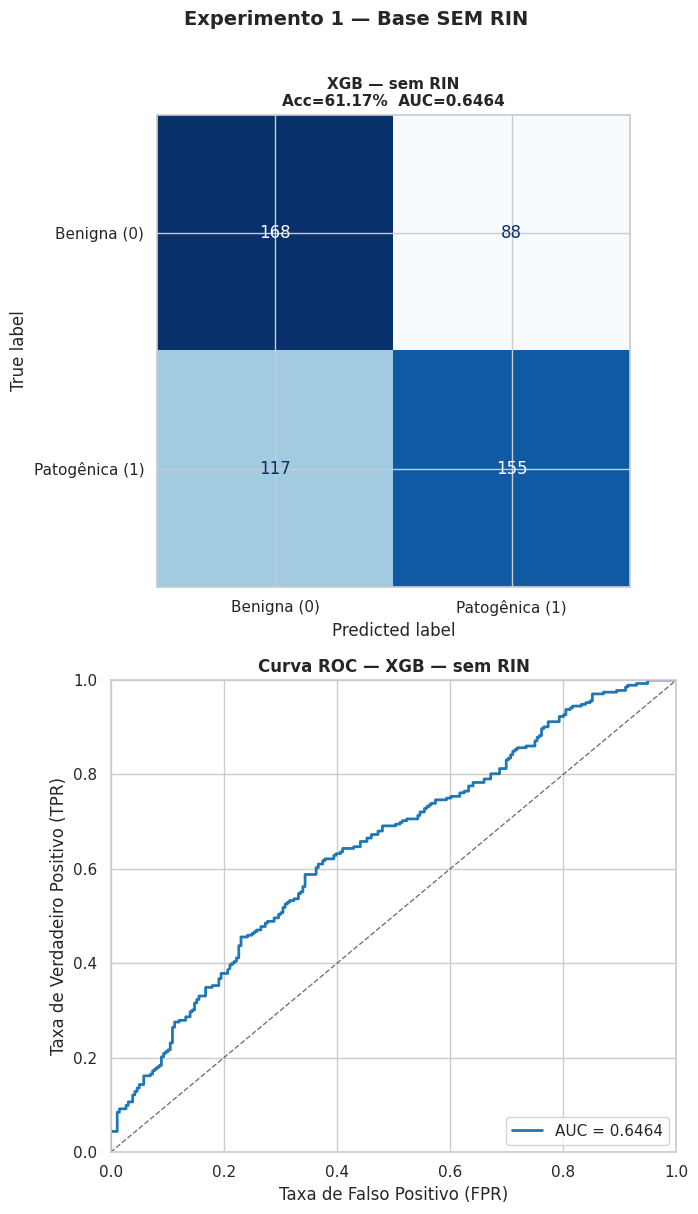


── Tabela de Métricas — Experimento 1 (SEM RIN) ──


,Acc. (%),TNR (%),NPV (%),TPR (%),PPV (%),ROC-AUC,F1-Score (%)
Modelo,,,,,,,
XGB — sem RIN,61.17,65.62,58.95,56.99,63.79,0.65,60.19


In [0]:
plot_resultados([res_xgb_sem], X_test_sem, y_test_sem_aligned, 'Experimento 1 — Base SEM RIN')
print('\n── Tabela de Métricas — Experimento 1 (SEM RIN) ──')
display(tabela_metricas([res_xgb_sem]))

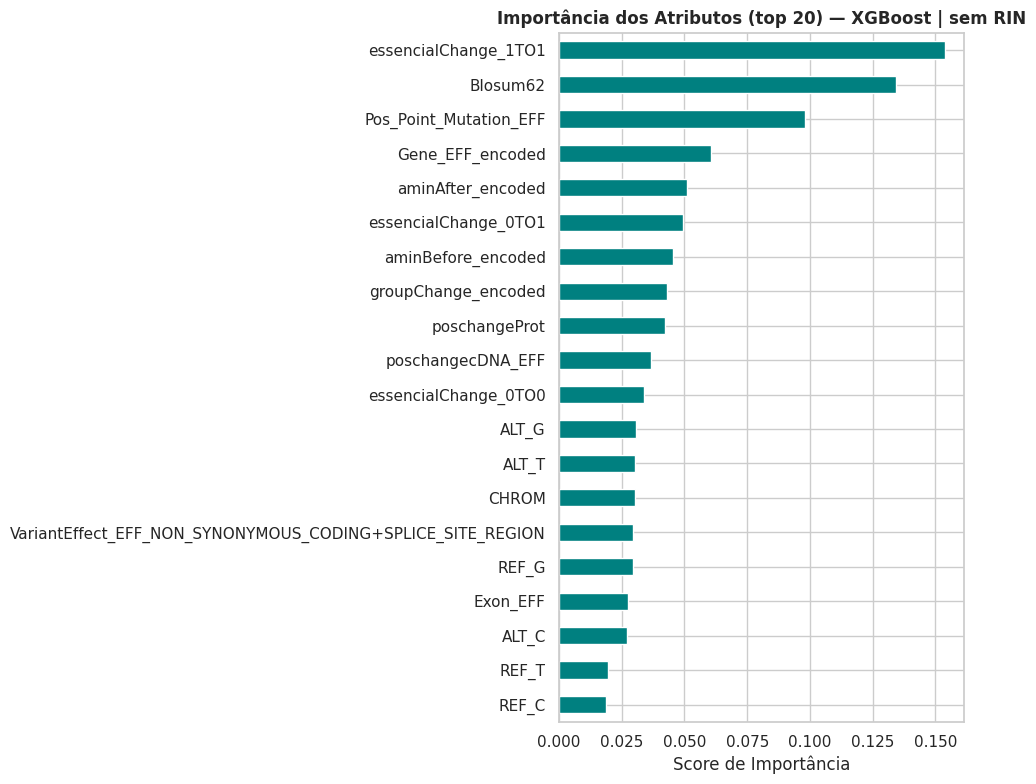

In [0]:
plot_feature_importance(xgb_sem, X_train_sem.columns, 'XGBoost | sem RIN', top_n=20)

## 7. XGBoost — COM RIN

Mesmo passo-a-passo do Experimento 1, agora com os atributos de RIN incluídos.

In [0]:
xgb_com = RandomizedSearchCV(
    estimator     = XGBClassifier(
        eval_metric       = 'logloss',
        use_label_encoder = False,
        random_state      = 42,
        verbosity         = 0,
    ),
    param_distributions = param_xgb,
    n_iter        = N_ITER,
    cv            = cv_strat,
    scoring       = scorers,
    refit         = REFIT,
    return_train_score = True,
    n_jobs        = -1,
    random_state  = SEED,
    verbose       = 1,
)

# Convert Blosum62 to numeric (it's stored as object dtype)
X_train_com['Blosum62'] = pd.to_numeric(X_train_com['Blosum62'], errors='coerce')

xgb_com.fit(X_train_com, y_train_com)

print('\nMelhores Hiperparâmetros (XGBoost | com RIN)')
for k, v in xgb_com.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nMelhor Accuracy (CV treino): {xgb_com.best_score_:.4f}')

Fitting 10 folds for each of 100 candidates, totalling 1000 fits

Melhores Hiperparâmetros (XGBoost | com RIN)
  colsample_bytree: 0.8405752468797338
  gamma: 0.20979263450306418
  learning_rate: 0.05984091249287084
  max_depth: 3
  min_child_weight: 2
  n_estimators: 336
  reg_alpha: 0.9662211351241645
  reg_lambda: 2.0860573343902233
  subsample: 0.9305721621259915

Melhor Accuracy (CV treino): 0.6876


In [0]:
# Convert Blosum62 to numeric in test set (same as training set)
X_test_com['Blosum62'] = pd.to_numeric(X_test_com['Blosum62'], errors='coerce')

res_xgb_com = avaliar_modelo('XGB - com RIN', xgb_com, X_test_com, y_test_com)
print('Métricas na base de TESTE (XGBoost | com RIN)')
for k, v in res_xgb_com.items():
    if not k.startswith('_'):
        print(f'  {k}: {v}')

Métricas na base de TESTE (XGBoost | com RIN)
  Modelo: XGB - com RIN
  Acc. (%): 67.74
  TNR (%): 62.4
  NPV (%): 65.71
  TPR (%): 72.28
  PPV (%): 69.3
  ROC-AUC: 0.7425
  F1-Score (%): 70.76


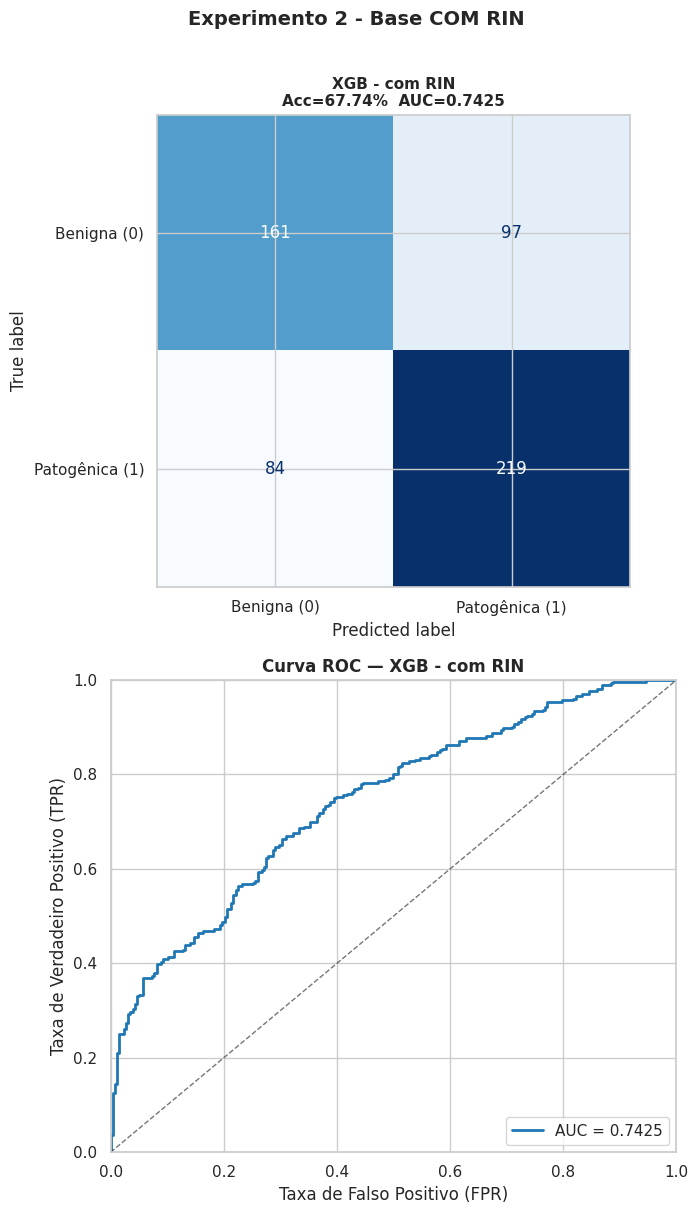


Tabela de Métricas - Experimento 2 (COM RIN)


,Acc. (%),TNR (%),NPV (%),TPR (%),PPV (%),ROC-AUC,F1-Score (%)
Modelo,,,,,,,
XGB - com RIN,67.74,62.40,65.71,72.28,69.30,0.74,70.76


In [0]:
plot_resultados([res_xgb_com], X_test_com, y_test_com, 'Experimento 2 - Base COM RIN')
print('\nTabela de Métricas - Experimento 2 (COM RIN)')
display(tabela_metricas([res_xgb_com]))

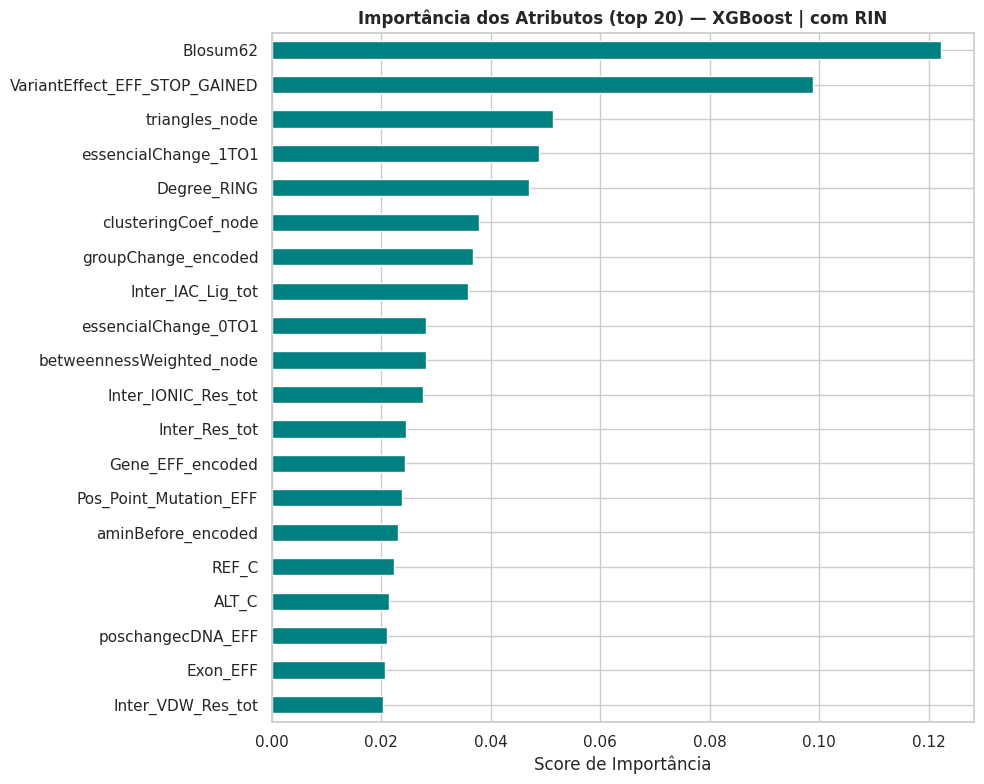

In [0]:
plot_feature_importance(xgb_com, X_train_com.columns, 'XGBoost | com RIN', top_n=20)

## 8. Comparação Geral — SEM RIN vs COM RIN

Tabela unificada e gráfico comparativo de todas as métricas.

In [0]:
todos = [res_xgb_sem, res_xgb_com]
cols  = ['Modelo', 'Acc. (%)', 'TNR (%)', 'NPV (%)',
         'TPR (%)', 'PPV (%)', 'ROC-AUC', 'F1-Score (%)']

df_comp = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')}
    for r in todos
])[cols].set_index('Modelo')

print('── Comparação Geral')
display(df_comp.style.highlight_max(axis=0, color='#d4edda').format(precision=2))

── Comparação Geral


,Acc. (%),TNR (%),NPV (%),TPR (%),PPV (%),ROC-AUC,F1-Score (%)
Modelo,,,,,,,
XGB — sem RIN,61.17,65.62,58.95,56.99,63.79,0.65,60.19
XGB - com RIN,67.74,62.40,65.71,72.28,69.30,0.74,70.76


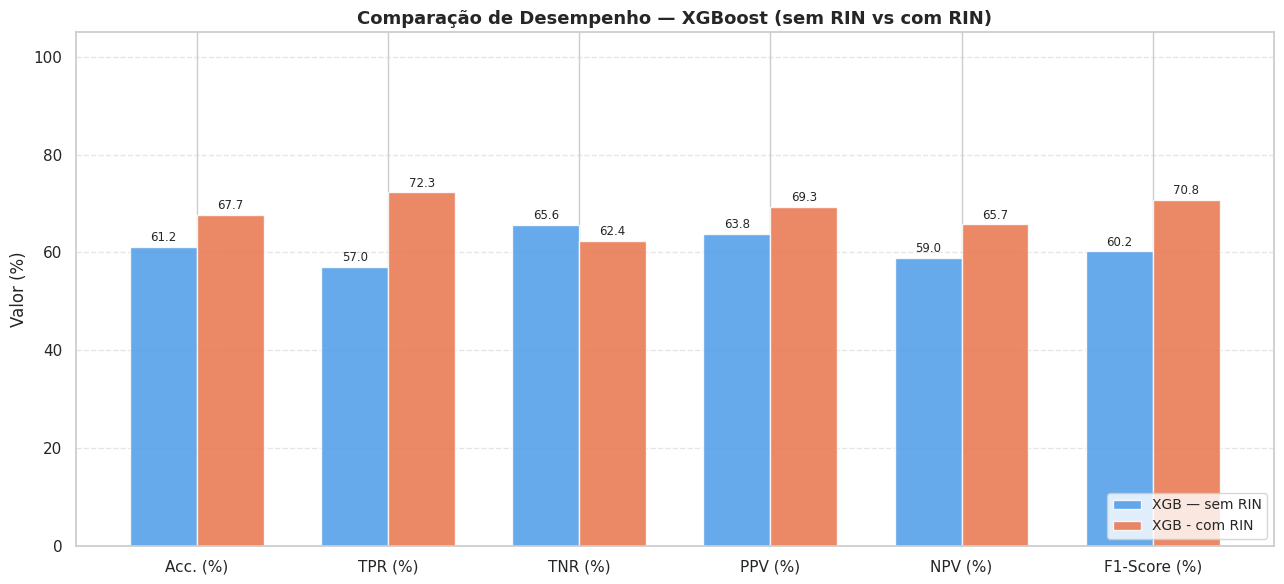

In [0]:
# Gráfico de barras comparativo
metricas_plot = ['Acc. (%)', 'TPR (%)', 'TNR (%)', 'PPV (%)', 'NPV (%)', 'F1-Score (%)']
df_plot = df_comp[metricas_plot].copy()

x     = np.arange(len(metricas_plot))
width = 0.35
cores = ['#4C9BE8', '#E8744C']
modelos = df_plot.index.tolist()

fig, ax = plt.subplots(figsize=(13, 6))
for i, (modelo, cor) in enumerate(zip(modelos, cores)):
    offset = (i - len(modelos) / 2 + 0.5) * width
    bars = ax.bar(x + offset, df_plot.loc[modelo], width,
                  label=modelo, color=cor, alpha=0.85, edgecolor='white')
    ax.bar_label(bars, fmt='%.1f', fontsize=8.5, padding=2)

ax.set_xticks(x)
ax.set_xticklabels(metricas_plot, fontsize=11)
ax.set_ylabel('Valor (%)', fontsize=12)
ax.set_title('Comparação de Desempenho — XGBoost (sem RIN vs com RIN)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(0, 105)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

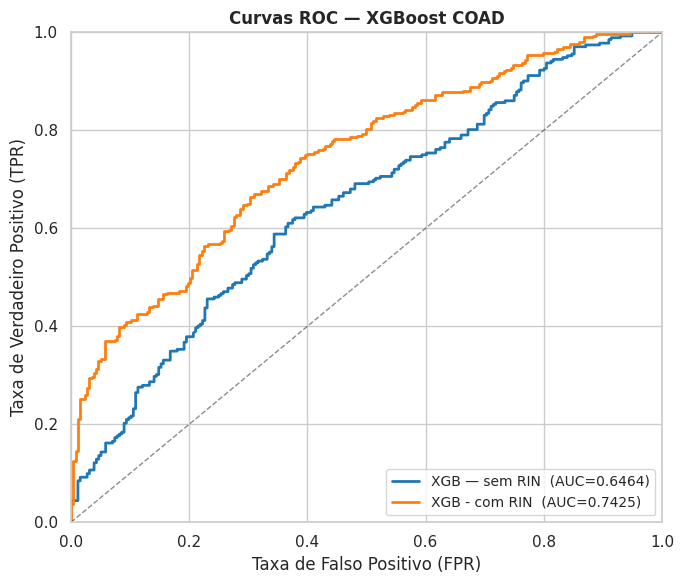

RESUMO FINAL

XGB — sem RIN
  Acc=61.17%  TPR=56.99%  TNR=65.62%  AUC=0.6464  F1=60.19%

XGB - com RIN
  Acc=67.74%  TPR=72.28%  TNR=62.40%  AUC=0.7425  F1=70.76%

→ Melhor ROC-AUC : XGB - com RIN (0.7425)
→ Melhor Acurácia: XGB - com RIN (67.74%)


In [0]:
# Curvas ROC sobrepostas
fig, ax = plt.subplots(figsize=(7, 6))
cores_roc = ['#1f77b4', '#ff7f0e']

for (res, y_t), cor in zip([(res_xgb_sem, y_test_sem_aligned), (res_xgb_com, y_test_com)], cores_roc):
    fpr, tpr_vals, _ = roc_curve(y_t, res['_y_proba'])
    ax.plot(fpr, tpr_vals, color=cor, lw=2,
            label=f'{res["Modelo"]}  (AUC={res["ROC-AUC"]:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('Taxa de Falso Positivo (FPR)')
ax.set_ylabel('Taxa de Verdadeiro Positivo (TPR)')
ax.set_title('Curvas ROC — XGBoost COAD', fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
plt.tight_layout()
plt.show()

# Resumo final impresso
print('=' * 70)
print('RESUMO FINAL')
print('=' * 70)
for res in todos:
    print(f"\n{res['Modelo']}")
    print(f"  Acc={res['Acc. (%)']:.2f}%  TPR={res['TPR (%)']:.2f}%  "
          f"TNR={res['TNR (%)']:.2f}%  AUC={res['ROC-AUC']:.4f}  "
          f"F1={res['F1-Score (%)']:.2f}%")

melhor_auc = max(todos, key=lambda r: r['ROC-AUC'])
melhor_acc = max(todos, key=lambda r: r['Acc. (%)'])
print(f"\n→ Melhor ROC-AUC : {melhor_auc['Modelo']} ({melhor_auc['ROC-AUC']:.4f})")
print(f"→ Melhor Acurácia: {melhor_acc['Modelo']} ({melhor_acc['Acc. (%)']:.2f}%)")